[ 6.  6.  6. ... 60. 60. 60.]


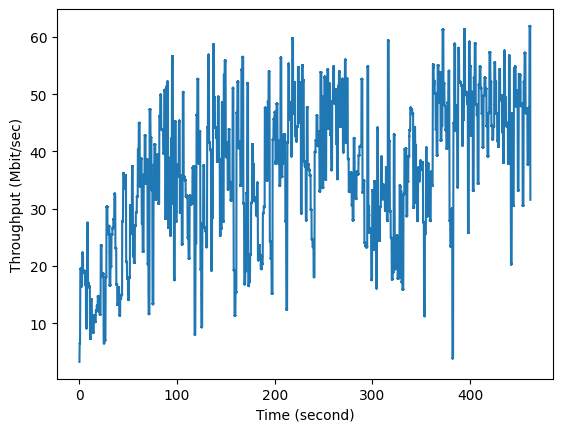

In [10]:
import numpy as np
import matplotlib.pyplot as plt


PACKET_SIZE = 1500.0  # bytes
BITS_IN_BYTE = 8.0
MBITS_IN_BITS = 1000000.0
MILLISECONDS_IN_SECONDS = 1000.0
N = 100
LINK_FILE = './mahimahi/report_foot_0008.log'


time_all = []
packet_sent_all = []
last_time_stamp = 0
packet_sent = 0
with open(LINK_FILE, 'rb') as f:
	for line in f:
		time_stamp = int(line.split()[0])
		if time_stamp == last_time_stamp:
			packet_sent += 1
			continue
		else:
			time_all.append(last_time_stamp)
			packet_sent_all.append(packet_sent)
			packet_sent = 1
			last_time_stamp = time_stamp

time_window = np.array(time_all[1:]) - np.array(time_all[:-1])
throuput_all = PACKET_SIZE * \
			   BITS_IN_BYTE * \
			   np.array(packet_sent_all[1:]) / \
			   time_window * \
			   MILLISECONDS_IN_SECONDS / \
			   MBITS_IN_BITS

print(throuput_all)
plt.plot(np.array(time_all[1:]) / MILLISECONDS_IN_SECONDS, 
		 np.convolve(throuput_all, np.ones(N,)/N, mode='same'))
plt.xlabel('Time (second)')
plt.ylabel('Throughput (Mbit/sec)')
plt.show()

In [1]:
print("test")

test
